<a href="https://colab.research.google.com/github/najafalinajaf449-hue/machine-learning/blob/main/023-24-0263_NajafAli_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LAB 6 ML Logistic Regression & KNN Classifications**



Name: Najaf Ali
Student ID: 023-24-0263
Section: CS V

GitHub Profile:https://github.com/najafalinajaf449-hue/machine-learning

Kaggle Profile: https://www.kaggle.com/najaf2ali
Dataset: Telco Customer Churn Dataset

In [12]:
#Task 1 upload churn.csv and verified its shape and dtypes
import pandas as pd
df_churn=pd.read_csv("clean_churn.csv")
df_churn.shape


(7043, 20)

In [4]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


## **TASK 2**
Lab 3's Decision Tree achieved a test accuracy of 0.7984, precision of 0.6347, recall of 0.5668, and F1-score of 0.5989. Lab 4's Random Forest achieved a test accuracy of 0.7857, precision of 0.6233, recall of 0.4866, and F1-score of 0.5465. These results provide the baseline benchmarks for comparing the Logistic Regression and KNN models in this lab.

In [16]:
#TASK 3 train x and y
# Define target variable
y = df_churn["Churn"].map({"Yes": 1, "No": 0})

# Define feature variables
X = df_churn.drop("Churn", axis=1)

# Find categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols)

# Check the result
print("Categorical columns encoded:", categorical_cols)
print("X shape:", X.shape)

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
X shape: (7043, 45)


# **TASK 4**
Feature scaling is important for KNN because KNN calculates distances between data points, so features with larger numerical ranges can have a greater influence on the distance calculation. Scaling also helps Logistic Regression work with features on comparable scales, while Decision Trees and Random Forests do not require scaling because they make decisions using feature-value thresholds rather than distance calculations.

In [17]:
#TASK 5 train test split
# TASK 5 — Train/Test Split and Feature Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data using the same strategy as Lab 3/4
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled data shapes:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train shape: (5634, 45)
X_test shape: (1409, 45)
y_train shape: (5634,)
y_test shape: (1409,)

Scaled data shapes:
X_train_scaled shape: (5634, 45)
X_test_scaled shape: (1409, 45)


The scaler is fitted only on the training data so that information from the test data does not influence the scaling process. After learning the scaling parameters from the training data, the same scaler is used to transform the test data, preventing data leakage and ensuring a fair evaluation.

In [18]:

# TASK 6 — Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logreg_model = LogisticRegression(random_state=42)

# Train the model using scaled training data
logreg_model.fit(X_train_scaled, y_train)

# Generate predictions on scaled test data
logreg_predictions = logreg_model.predict(X_test_scaled)

# Display first few predictions
print("First 20 predictions:")
print(logreg_predictions[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [19]:
# TASK 7 — Logistic Regression Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate metrics
logreg_accuracy = accuracy_score(y_test, logreg_predictions)
logreg_precision = precision_score(y_test, logreg_predictions)
logreg_recall = recall_score(y_test, logreg_predictions)
logreg_f1 = f1_score(y_test, logreg_predictions)

# Display results
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logreg_accuracy)
print("Precision:", logreg_precision)
print("Recall   :", logreg_recall)
print("F1-score :", logreg_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1-score : 0.6091954022988506


In [20]:
# Confusion Matrix

cm_logreg = confusion_matrix(y_test, logreg_predictions)

print("\nConfusion Matrix:")
print(cm_logreg)


Confusion Matrix:
[[925 110]
 [162 212]]


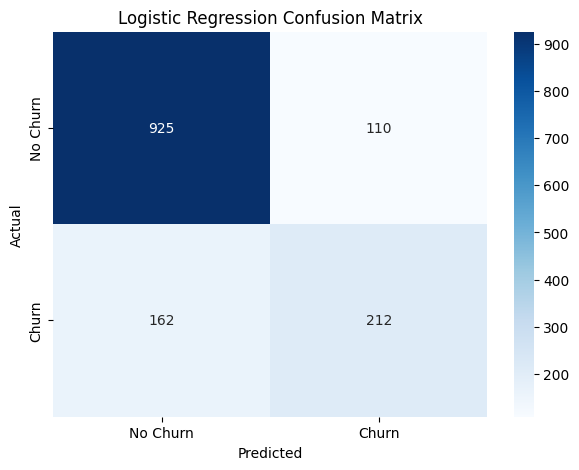

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [22]:
logreg_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        logreg_accuracy,
        logreg_precision,
        logreg_recall,
        logreg_f1
    ]
})

display(logreg_results)

,Metric,Score
0,Accuracy,0.806955
1,Precision,0.658385
2,Recall,0.566845
3,F1-score,0.609195


In [23]:
# TASK 8 — Predicted Probabilities

# Get probability predictions for the first 10 test customers
probabilities = logreg_model.predict_proba(X_test_scaled)

print("Predicted probabilities for first 10 customers:")
print(probabilities[:10])

Predicted probabilities for first 10 customers:
[[0.95446568 0.04553432]
 [0.31655726 0.68344274]
 [0.94389474 0.05610526]
 [0.59161194 0.40838806]
 [0.97835685 0.02164315]
 [0.39644444 0.60355556]
 [0.54848864 0.45151136]
 [0.86869905 0.13130095]
 [0.99721298 0.00278702]
 [0.60587573 0.39412427]]


predict_proba() returns the model's estimated probability for each class, where the first column represents No Churn and the second represents Churn. predict() converts these probabilities into a class prediction by selecting the class with the higher predicted probability.

In [24]:
# TASK 9 — KNN with Different K Values

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# K values required by the lab
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

# Store results
knn_results = []

# Train and evaluate KNN for each K
for k in k_values:

    # Create KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn_model.fit(X_train_scaled, y_train)

    # Make predictions
    knn_predictions = knn_model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, knn_predictions)
    f1 = f1_score(y_test, knn_predictions)

    # Store results
    knn_results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1-score": f1
    })

# Convert results to DataFrame
knn_results_df = pd.DataFrame(knn_results)

# Display results
display(knn_results_df)

,K,Accuracy,F1-score
0,1,0.712562,0.469201
1,3,0.738112,0.508655
2,5,0.748758,0.522911
3,7,0.753016,0.529730
4,9,0.768630,0.553425
5,11,0.761533,0.535912
6,15,0.772179,0.554785
7,21,0.775727,0.564738


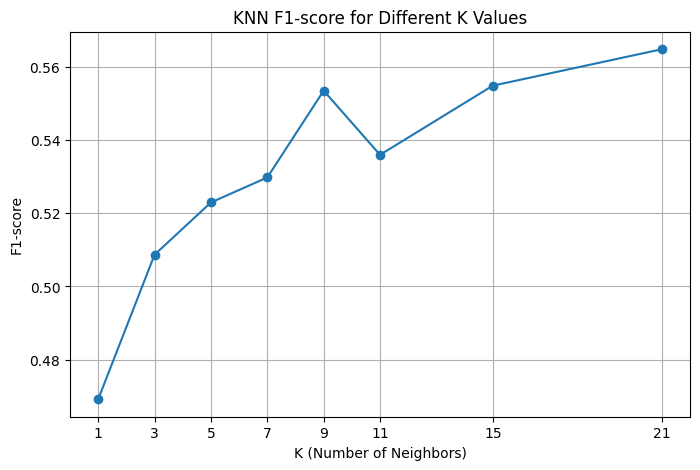

In [25]:
# Plot F1-score against K

plt.figure(figsize=(8, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["F1-score"],
    marker="o"
)

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("F1-score")
plt.title("KNN F1-score for Different K Values")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [26]:
# TASK 10 — Select K based on F1-score

best_k_row = knn_results_df.loc[
    knn_results_df["F1-score"].idxmax()
]

print("Best K based on F1-score:", best_k_row["K"])
print("Accuracy:", best_k_row["Accuracy"])
print("F1-score:", best_k_row["F1-score"])

Best K based on F1-score: 21.0
Accuracy: 0.7757274662881476
F1-score: 0.5647382920110193


Based on the KNN results, I selected K = 21.0 because it produced the highest F1-score of 0.5647382920110193 while maintaining an accuracy of 0.7757274662881476. I did not simply choose the smallest K because a very small K can make the model sensitive to individual noisy observations, while choosing a very large K can make the model too general and potentially underfit.

In [27]:
# TASK 11 — Final KNN Model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Use the K selected in Task 10
best_k = int(best_k_row["K"])

# Create final KNN model
final_knn = KNeighborsClassifier(n_neighbors=best_k)

# Train using scaled training data
final_knn.fit(X_train_scaled, y_train)

# Predictions
knn_final_predictions = final_knn.predict(X_test_scaled)

print("Selected K:", best_k)

Selected K: 21


In [28]:
# Calculate evaluation metrics

knn_accuracy = accuracy_score(y_test, knn_final_predictions)
knn_precision = precision_score(y_test, knn_final_predictions)
knn_recall = recall_score(y_test, knn_final_predictions)
knn_f1 = f1_score(y_test, knn_final_predictions)

print("\n--- Final KNN Results ---")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-score :", knn_f1)


--- Final KNN Results ---
Accuracy : 0.7757274662881476
Precision: 0.5823863636363636
Recall   : 0.5481283422459893
F1-score : 0.5647382920110193


In [29]:
# Confusion Matrix

knn_cm = confusion_matrix(y_test, knn_final_predictions)

print("\nConfusion Matrix:")
print(knn_cm)


Confusion Matrix:
[[888 147]
 [169 205]]


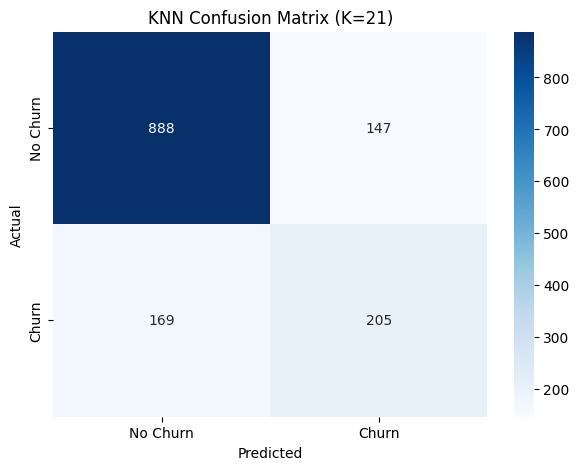

In [30]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

The final KNN model with K = 21 achieved an accuracy of 0.7757274662881476, precision of  0.5823863636363636_, recall of 0.5481283422459893, and F1-score of 0.5647382920110193. The confusion matrix shows that the model correctly identified 205 actual churners while missing 169 actual churners.

In [31]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        0.798439,
        0.785664,
        logreg_accuracy,
        knn_accuracy
    ],
    "Precision": [
        0.634731,
        0.623288,
        logreg_precision,
        knn_precision
    ],
    "Recall": [
        0.566845,
        0.486631,
        logreg_recall,
        knn_recall
    ],
    "F1-score": [
        0.598870,
        0.546547,
        logreg_f1,
        knn_f1
    ]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.798439,0.634731,0.566845,0.598870
1,Random Forest,0.785664,0.623288,0.486631,0.546547
2,Logistic Regression,0.806955,0.658385,0.566845,0.609195
3,KNN,0.775727,0.582386,0.548128,0.564738


The four models were compared using accuracy, precision, recall, and F1-score. Decision Tree and Random Forest results were taken from the previous labs, while Logistic Regression and KNN were evaluated in this lab using the same test set. The comparison allows the performance of all four models to be assessed using the same metrics. Since the dataset contains class imbalance, recall and F1-score are particularly important when evaluating churn predictio

# TASK 13
Among the four models, Logistic Regression achieved the highest accuracy (0.8070), precision (0.6584), and F1-score (0.6092). Decision Tree and Logistic Regression achieved the same recall of 0.5668, while Random Forest had the lowest recall of 0.4866. Therefore, the ordering of models changes depending on the evaluation metric, although Logistic Regression has the strongest results across most of the metrics in this test-set comparison. Because the churn dataset has class imbalance, accuracy alone should not be used to judge model performance. Recall and F1-score are particularly important because they provide more information about the model's ability to identify the minority churn class.

In [33]:
#TASK 14
import numpy as np
import pandas as pd

coefficients = logreg_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Odds Ratio",
    ascending=False
)

display(coef_df)

,Feature,Coefficient,Odds Ratio
3,TotalCharges,0.531200,1.700972
16,InternetService_Fiber optic,0.440579,1.553607
36,Contract_Month-to-month,0.306581,1.358772
32,StreamingTV_Yes,0.187716,1.206490
35,StreamingMovies_Yes,0.187647,1.206408
14,MultipleLines_Yes,0.121607,1.129310
43,PaymentMethod_Electronic check,0.121482,1.129170
18,OnlineSecurity_No,0.114937,1.121802
27,TechSupport_No,0.103287,1.108809
40,PaperlessBilling_Yes,0.091094,1.095372


In [34]:
top_features = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
).head(4)

display(top_features)

,Feature,Coefficient,Odds Ratio
1,tenure,-1.252707,0.285730
2,MonthlyCharges,-1.003050,0.366759
3,TotalCharges,0.531200,1.700972
16,InternetService_Fiber optic,0.440579,1.553607


Logistic Regression coefficients and odds ratios were examined to understand the relationship between the input features and customer churn. The four strongest effects based on the absolute coefficient values were tenure, MonthlyCharges, TotalCharges, and InternetService_Fiber optic. Tenure had the largest absolute coefficient (-1.2527) and an odds ratio of 0.2857, indicating that higher standardized tenure is associated with lower odds of churn. MonthlyCharges had a coefficient of -1.0031 and an odds ratio of 0.3668, while TotalCharges had a positive coefficient of 0.5312 and an odds ratio of 1.7010. InternetService_Fiber optic had a coefficient of 0.4406 and an odds ratio of 1.5536, indicating higher modeled odds of churn relative to its reference category. These coefficients describe associations within the fitted Logistic Regression model and should be interpreted while considering the effects of other features in the mode

# TASK 15
he Logistic Regression coefficients were compared with the important features identified through EDA and tree-based feature importance. There is considerable agreement between the approaches, particularly for tenure, MonthlyCharges, TotalCharges, and InternetService. Logistic Regression identified tenure and MonthlyCharges as having large coefficient magnitudes, while TotalCharges and Fiber optic InternetService also showed relatively strong effects. The previous tree-based analysis similarly identified Contract_Month-to-month, InternetService_Fiber optic, tenure, TotalCharges, and MonthlyCharges as important features. The agreement suggests that these variables contain useful information for predicting customer churn. However, the methods measure importance differently: Logistic Regression uses coefficients to represent conditional associations, whereas tree models measure feature importance based on how features contribute to tree splits

# TASK 16
Based on the test-set comparison, Logistic Regression was selected as the final model for this experiment. It achieved an accuracy of 0.8070, precision of 0.6584, recall of 0.5668, and F1-score of 0.6092. It achieved the highest accuracy, precision, and F1-score among the four models, while its recall was equal to that of the Decision Tree. Since the dataset has class imbalance, F1-score and recall were considered alongside accuracy when making the selection. The previous lab also demonstrated the importance of cross-validation when evaluating model performance, so the final selection should ideally be confirmed using cross-validation rather than relying only on one test split.

#TASK 17

In this lab, Logistic Regression and KNN were trained and compared with the Decision Tree and Random Forest models from the previous labs. Logistic Regression achieved the highest accuracy (0.8070), precision (0.6584), and F1-score (0.6092), while its recall of 0.5668 was equal to the Decision Tree. KNN achieved an accuracy of 0.7757 and an F1-score of 0.5647, while Random Forest achieved an accuracy of 0.7857 and an F1-score of 0.5465. The Logistic Regression analysis identified tenure, MonthlyCharges, TotalCharges, and InternetService_Fiber optic as features with relatively strong effects. The comparison with the previous tree-based analysis showed agreement on several important predictive features, including tenure, MonthlyCharges, TotalCharges, and InternetService. Because the dataset contains class imbalance, recall and F1-score were considered alongside accuracy when evaluating the models. Based on the test-set results, Logistic Regression was selected as the final model for this experiment, while cross-validation can provide additional evidence about its generalization performance.